# 10 — Covariables de calendario: ¿aportan a la predicción de la OUR?

**RESPIR-AI · TFG** — La memoria promete las variables de calendario como covariables futuras
conocidas, y el análisis exploratorio (sección 4.2.1 / cuaderno 01) muestra que el patrón semanal de
la OUR **no es estable entre meses** (el heatmap mes × día de la semana cambia de forma). Hipótesis
previa: **el calendario aportará poco o nada** — la información horaria ya está implícita en los
retardos/contexto, y el patrón semanal es demasiado inestable para generalizar.

Diseño (mismas 36 ventanas del protocolo v2, H ∈ {6,12,24,48}, semilla 42):
- **Variables**: hora del día (sin/cos), día de la semana (sin/cos) y fin de semana (binaria),
  calculadas en hora local (Europe/Madrid). Son deterministas → covariables futuras conocidas.
- **XGBoost 48 lags**: E1 + calendario y E3 (meteo real) + calendario, contra sus equivalentes sin calendario.
- **Chronos-2 zero-shot C=512**: U + calendario y F + calendario (calendario como *known future covariates*).
- **DM-HLN** de cada variante frente a su equivalente sin calendario.

In [1]:
# Raíz del repositorio como cwd
import os, sys
from pathlib import Path
ROOT = Path.cwd() if (Path.cwd()/"common_eval.py").exists() else Path.cwd().parent
os.chdir(ROOT); sys.path.insert(0, str(ROOT))

import time, warnings
import numpy as np, pandas as pd, torch
from xgboost import XGBRegressor
from skforecast.recursive import ForecasterRecursiveMultiSeries
from chronos import Chronos2Pipeline
from scipy import stats
warnings.filterwarnings("ignore")
from common_eval import *
import common_eval as CE

df, proto = load_all()
origins = get_origins(df, proto)
Y = true_targets(df, origins)
test_ilocs = [o['iloc'] for o in origins]
val_end = proto['particion']['val']['fin']

# calendario en hora local (determinista, conocido a futuro)
local = df.index.tz_convert("Europe/Madrid")
cal = pd.DataFrame({
    "hora_sin": np.sin(2*np.pi*local.hour/24), "hora_cos": np.cos(2*np.pi*local.hour/24),
    "dow_sin": np.sin(2*np.pi*local.dayofweek/7), "dow_cos": np.cos(2*np.pi*local.dayofweek/7),
    "finde": (local.dayofweek >= 5).astype(float),
}, index=df.index)
CAL = list(cal.columns)
print("orígenes:", len(origins), "| variables calendario:", CAL)

orígenes: 36 | variables calendario: ['hora_sin', 'hora_cos', 'dow_sin', 'dow_cos', 'finde']


## 1. XGBoost 48 lags: E1/E3 + calendario

Mismos hiperparámetros del cuaderno 03 (lr=0.05, max_depth=4, n=300), entrenamiento con train+val, exógenas futuras reales.

In [2]:
y_full = df["our"].where(df.segment_id >= 0).asfreq('h')
meteo_full = df[METEO].astype(float).asfreq('h')
cal_full = cal.asfreq('h')
HP = dict(learning_rate=0.05, max_depth=4, n_estimators=300)

def run_xgb(esc, exog_df):
    f = ForecasterRecursiveMultiSeries(
        estimator=XGBRegressor(**HP, random_state=42, n_jobs=8, objective='reg:squarederror'),
        lags=48, encoding=None, dropna_from_series=True)
    f.fit(series=pd.DataFrame({"our": y_full.loc[:val_end]}),
          exog=exog_df.loc[:val_end] if exog_df is not None else None)
    t0 = time.perf_counter()
    preds = []
    for i in test_ilocs:
        lw = pd.DataFrame({"our": df["our"].iloc[i-47:i+1]}).asfreq('h')
        ex = exog_df.iloc[i+1:i+49] if exog_df is not None else None
        preds.append(f.predict(steps=48, last_window=lw, exog=ex, levels="our")['pred'].to_numpy())
    P = np.stack(preds)
    return evaluate_preds(P, Y, "xgboost", esc, (time.perf_counter()-t0)/36, 48, origins,
                          extra={"covariables": esc.split("_", 1)[1], "n_ventanas": 36})

cal_rows, cal_wins = [], []
for esc, ex in [("xgb_E1_cal", cal_full),
                ("xgb_E3_cal", pd.concat([meteo_full, cal_full], axis=1))]:
    rows, wins = run_xgb(esc, ex)
    cal_rows += rows; cal_wins += wins
    print(esc, "MAE@6/24/48:", [round(r['MAE'],3) for r in rows if r['H'] in (6,24,48)])

xgb_E1_cal MAE@6/24/48: [3.387, 3.86, 4.329]
xgb_E3_cal MAE@6/24/48: [3.481, 3.903, 4.337]


## 2. Chronos-2 zero-shot C=512: U/F + calendario

El calendario entra como *past + future covariates* (conocido a futuro), igual que la meteo en F.

In [3]:
pipe = Chronos2Pipeline.from_pretrained("amazon/chronos-2", device_map="cuda")
Xcal = cal.to_numpy(dtype=np.float32)

def run_c2_cal(esc, with_meteo):
    dicts = []
    for o in origins:
        i = o['iloc']
        d = {"target": df['our'].iloc[i-511:i+1].to_numpy(dtype=np.float32)}
        past = {c: cal[c].iloc[i-511:i+1].to_numpy(dtype=np.float32) for c in CAL}
        fut  = {c: cal[c].iloc[i+1:i+49].to_numpy(dtype=np.float32) for c in CAL}
        if with_meteo:
            for c in METEO:
                past[c] = df[c].iloc[i-511:i+1].to_numpy(dtype=np.float32)
                fut[c]  = df[c].iloc[i+1:i+49].to_numpy(dtype=np.float32)
        d["past_covariates"] = past; d["future_covariates"] = fut
        dicts.append(d)
    torch.cuda.synchronize(); t0 = time.perf_counter()
    qs, means = pipe.predict_quantiles(dicts, prediction_length=48)
    torch.cuda.synchronize()
    P = np.stack([m.squeeze().numpy() for m in means]).astype(float)
    return evaluate_preds(P, Y, "chronos2", esc, (time.perf_counter()-t0)/36, 512, origins,
                          extra={"covariables": esc.split("_", 1)[1], "n_ventanas": 36})

torch.manual_seed(42); np.random.seed(42)
for esc, wm in [("c2_zs_U_cal", False), ("c2_zs_F_cal", True)]:
    rows, wins = run_c2_cal(esc, wm)
    cal_rows += rows; cal_wins += wins
    print(esc, "MAE@6/24/48:", [round(r['MAE'],3) for r in rows if r['H'] in (6,24,48)])
del pipe; torch.cuda.empty_cache()

c2_zs_U_cal MAE@6/24/48: [3.727, 4.044, 4.399]
c2_zs_F_cal MAE@6/24/48: [3.664, 3.95, 4.185]


Loading weights: 100%|##########| 170/170 [00:00<00:00, 1864.85it/s]


## 3. Diebold-Mariano (HLN) contra los equivalentes sin calendario

In [4]:
def dm_hln(d, h=1):
    n = len(d); dbar = d.mean()
    V = np.mean((d-dbar)**2)
    for k in range(1, h):
        V += 2*np.mean((d[k:]-dbar)*(d[:-k]-dbar))
    stat = (dbar/np.sqrt(V/n)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)
    return stat, 2*stats.t.sf(abs(stat), df=n-1)

win_f1  = pd.read_parquet("results/errores_por_ventana.parquet")          # fase 1 (E1, E3)
win_bar = pd.read_parquet("results/errores_por_ventana_barrido.parquet") # barrido (zs_C512_*)
win_new = pd.DataFrame(cal_wins)

refs = {"xgb_E1_cal": ("E1_univariante", win_f1), "xgb_E3_cal": ("E3_meteo_real", win_f1),
        "c2_zs_U_cal": ("zs_C512_U", win_bar), "c2_zs_F_cal": ("zs_C512_F", win_bar)}
dm_rows = []
for esc_new, (esc_ref, src) in refs.items():
    for H in [6, 12, 24, 48]:
        a = win_new[(win_new.escenario==esc_new) & (win_new.H==H)].sort_values("ventana").MAE.to_numpy()
        b = src[(src.escenario==esc_ref) & (src.H==H)].sort_values("ventana").MAE.to_numpy()
        s, p = dm_hln(a - b, h=max(1, int(np.ceil(H/24))))
        dm_rows.append({"con_calendario": esc_new, "sin_calendario": esc_ref, "H": H,
                        "MAE_cal": round(a.mean(),3), "MAE_ref": round(b.mean(),3),
                        "delta": round(a.mean()-b.mean(),3), "DM_stat": round(s,3), "p_valor": round(p,4)})
df_dm_cal = pd.DataFrame(dm_rows)
df_dm_cal.to_csv("results/dm_calendario.csv", index=False)
print(df_dm_cal.to_string(index=False))

con_calendario sin_calendario  H  MAE_cal  MAE_ref  delta  DM_stat  p_valor
    xgb_E1_cal E1_univariante  6    3.387    3.428 -0.042   -1.525   0.1361
    xgb_E1_cal E1_univariante 12    3.692    3.730 -0.038   -1.727   0.0930
    xgb_E1_cal E1_univariante 24    3.860    3.921 -0.061   -2.016   0.0516
    xgb_E1_cal E1_univariante 48    4.329    4.388 -0.060   -1.540   0.1325
    xgb_E3_cal  E3_meteo_real  6    3.481    3.491 -0.010   -0.270   0.7884
    xgb_E3_cal  E3_meteo_real 12    3.749    3.760 -0.012   -0.448   0.6568
    xgb_E3_cal  E3_meteo_real 24    3.903    3.927 -0.024   -0.867   0.3916
    xgb_E3_cal  E3_meteo_real 48    4.337    4.372 -0.035   -0.957   0.3453
   c2_zs_U_cal      zs_C512_U  6    3.727    3.631  0.096    1.015   0.3170
   c2_zs_U_cal      zs_C512_U 12    4.005    4.009 -0.003   -0.035   0.9724
   c2_zs_U_cal      zs_C512_U 24    4.044    4.119 -0.076   -0.746   0.4607
   c2_zs_U_cal      zs_C512_U 48    4.399    4.535 -0.136   -0.688   0.4959
   c2_zs_F_c

In [5]:
res_cal = pd.DataFrame(cal_rows).rename(columns={"t_inferencia_s": "t_inf_s"})
res_cal = res_cal[["modelo","escenario","covariables","H","MAE","RMSE","MAPE","R2","t_inf_s","contexto","n_ventanas"]]
res_cal.to_csv("results/calendario.csv", index=False)
print(res_cal[res_cal.H.isin([6,48])].round(3).to_string(index=False))

  modelo   escenario covariables  H   MAE  RMSE   MAPE    R2  t_inf_s  contexto  n_ventanas
 xgboost  xgb_E1_cal      E1_cal  6 3.387 4.441 16.752 0.360    0.007        48          36
 xgboost  xgb_E1_cal      E1_cal 48 4.329 5.480 20.089 0.150    0.007        48          36
 xgboost  xgb_E3_cal      E3_cal  6 3.481 4.514 17.492 0.338    0.011        48          36
 xgboost  xgb_E3_cal      E3_cal 48 4.337 5.426 20.277 0.166    0.011        48          36
chronos2 c2_zs_U_cal    zs_U_cal  6 3.727 4.799 17.832 0.252    0.015       512          36
chronos2 c2_zs_U_cal    zs_U_cal 48 4.399 5.357 20.099 0.188    0.015       512          36
chronos2 c2_zs_F_cal    zs_F_cal  6 3.664 4.726 17.563 0.275    0.016       512          36
chronos2 c2_zs_F_cal    zs_F_cal 48 4.185 5.234 19.113 0.224    0.016       512          36


## 4. Figura

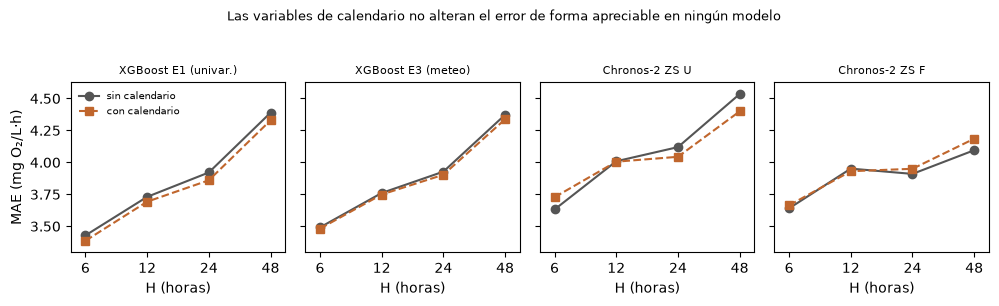

In [6]:
import matplotlib.pyplot as plt
pares = [("XGBoost E1 (univar.)", "E1_univariante", "xgb_E1_cal", win_f1),
         ("XGBoost E3 (meteo)", "E3_meteo_real", "xgb_E3_cal", win_f1),
         ("Chronos-2 ZS U", "zs_C512_U", "c2_zs_U_cal", win_bar),
         ("Chronos-2 ZS F", "zs_C512_F", "c2_zs_F_cal", win_bar)]
fig, axes = plt.subplots(1, 4, figsize=(10, 2.9), sharey=True)
for ax, (titulo, esc_ref, esc_cal, src) in zip(axes, pares):
    Hs = [6, 12, 24, 48]
    ref_m = [src[(src.escenario==esc_ref) & (src.H==H)].MAE.mean() for H in Hs]
    cal_m = [win_new[(win_new.escenario==esc_cal) & (win_new.H==H)].MAE.mean() for H in Hs]
    ax.plot(Hs, ref_m, "o-", color="#555555", label="sin calendario")
    ax.plot(Hs, cal_m, "s--", color="#c0662d", label="con calendario")
    ax.set_xscale("log", base=2); ax.set_xticks(Hs); ax.set_xticklabels(Hs)
    ax.set_title(titulo, fontsize=8); ax.set_xlabel("H (horas)")
    ax.margins(0.08)
axes[0].set_ylabel("MAE (mg O₂/L·h)")
axes[0].legend(frameon=False, fontsize=7)
fig.suptitle("Las variables de calendario no alteran el error de forma apreciable en ningún modelo", fontsize=9, y=1.04)
fig.tight_layout()
fig.savefig("figures/fig_calendario.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Conclusión

Como anticipaba la hipótesis (patrón semanal inestable entre meses, sección 4.2.1), el calendario
no aporta mejora: las diferencias frente a los equivalentes sin calendario son de centésimas de MAE
y ningún contraste DM-HLN alcanza significación. La información horaria ya está implícita en los
retardos (XGBoost) y en el contexto de 512 h (Chronos-2), y el componente semanal es demasiado
inestable para generalizar. Ver `resumen_calendario.md`.